# Behavior Analysis - episodic memory and statistical learning

## 0. Initialization and helper functions

In [1]:
import warnings
import numpy as np
import pandas as pd
import scipy.stats as st 
from matplotlib import pyplot as plt
from scipy import stats
import seaborn as sns
from utils import *
from matplotlib.lines import Line2D
from itertools import combinations

%run behav_starter.py

warnings.filterwarnings('ignore', category=FutureWarning)


Controls:  47
Stress:  49


In [2]:
def behavfamil_savepath():
    scratch_dir = "./midpoints/behavior/"
    scratch_outfile = f"{scratch_dir}behav_famil.csv"
        
    return scratch_outfile

def behavrecog_savepath():
    scratch_dir = "./midpoints/behavior/"
    scratch_outfile = f"{scratch_dir}behav_recog.csv"

    return scratch_outfile

## 1. Episodic memory / item recognition (Figure 3A)

In [3]:
def A_prime(HR, FA):
    """
    Computes the A-prime statistic given a subject's hit rate and false alarm, based on Stanislav & Todorov 1999. 
    HR and FA can be provided for multiple subjects in 1D numpy array form, and function will return a list of A' values in the same format. 
    
    A' = 0.5 + sign(H-F)*((H-F)^2 + abs(H-F))/(4*max(H,F) - 4*H*F)
    
    Args:
        HR (float OR np.array(float)): hit rate ("yes"|old)
        FA (float OR np.array(float)): false alarm ("yes"|new)
    Returns:
        (float OR np.array(float)): A' statistic in the same format as HR and FA
    """
    assert type(HR) == type(FA)
    if type(HR) is np.ndarray:
        assert HR.shape == FA.shape
        
    Aprime = 0.5 + np.sign(HR - FA)*((HR - FA)**2 + np.abs(HR - FA))/(4*np.max([HR, FA], axis=0) - 4*HR*FA)
    return Aprime


def behav_stats(subIDs, stat_type, conds = ['A', 'B', 'X']):
    '''
    No-respose is excluded from stat and trial count
    Args: 
        subIDs (list(int)): list of subject IDs to use
        stat_type (str): one of ["Aprime", "HR", "FA"]
        conds (list(str)): subset of ['A', 'B', 'X'] over which to compute stats
    '''

    recog = pd.read_csv(f'{behav_dir}/recognitionData.csv', sep='\t')
    recog["resp"] = recog["resp"].apply(lambda x: not pd.isna(x))

    # trials with no response are omitted from statistics and trial counts
    recog_summ = recog[['subid', 'cond', 'old_new', 'acc', 'trial', 'resp']].groupby(['subid', 'cond', 'old_new', 'acc', 'resp'], as_index=True, dropna=False).count().unstack(fill_value=0).stack().reset_index()
    recog_summ = recog_summ[recog_summ["resp"]]
    
    
    # count how many trials in each condition
    # Hit rate: old_new = 1, acc = 1; out of all olds, proportion correct
    # False alarm; old_new = 2, acc = 0; out of all news, proportion incorrect
    stats = []
    
    for sub in subIDs:
        if stat_type == "HR" or stat_type == "Aprime":
            HR_df = recog_summ.loc[(recog_summ['subid'] == sub) & (np.isin(recog_summ['cond'], conds)) & (recog_summ['old_new'] == 1)]
            HR_total = np.sum(HR_df["trial"])
            HR_numerator_df = HR_df.loc[(HR_df['acc'] == 1) & (HR_df['resp'] == True)]
            HR_numerator = np.sum(HR_numerator_df["trial"])
            HR = HR_numerator/HR_total
    
            if stat_type == "HR":
                stat = HR
            
        if stat_type == "FA" or stat_type == "Aprime":
            FA_df = recog_summ.loc[(recog_summ['subid'] == sub) & (np.isin(recog_summ['cond'], conds)) & (recog_summ['old_new'] == 2)]
            FA_total = np.sum(FA_df["trial"])
            FA_numerator_df = FA_df.loc[(FA_df['acc'] == 0) & (FA_df['resp'] == True)]
            FA_numerator = np.sum(FA_numerator_df["trial"])
            FA = FA_numerator/FA_total
    
            if stat_type == "FA":
                stat = FA
    
        if stat_type == "Aprime":
            stat = A_prime(HR, FA)
    
        stats.append(stat)

    return stats
        


A Control: 95% CI [0.61831, 0.65943], p=0.0
B Control: 95% CI [0.59128, 0.64517], p=0.0
X Control: 95% CI [0.58931, 0.63125], p=0.0
A Stress: 95% CI [0.58558, 0.62835], p=0.0
B Stress: 95% CI [0.56781, 0.61171], p=0.0
X Stress: 95% CI [0.59497, 0.63457], p=0.0

A Stress v Control: 95% CI [-0.06141, -0.00217], p = 0.03492, rbc = -0.23535
B Stress v Control: 95% CI [-0.06317, 0.00634], p = 0.10742, rbc = -0.22753
X Stress v Control: 95% CI [-0.02449, 0.03346], p = 0.75109, rbc = 0.0482

A vs X Control: 95% CI [0.00485, 0.05236], p=0.01858, r=0.34574
B vs X Control: 95% CI [-0.01885, 0.03464], p=0.54035, r=0.12589
A vs X Stress: 95% CI [-0.03153, 0.01627], p=0.52015, r=-0.08898
B vs X Stress: 95% CI [-0.05044, 0.00118], p=0.0615, r=-0.32408
stat ~ group * ABX + (1 | subID)


             numDF  denDF       F-value   p-value
(Intercept)      1  188.0  10652.801080  0.000000
group            1   94.0      2.453745  0.120605
ABX              2  188.0      1.979954  0.140944
group:ABX        

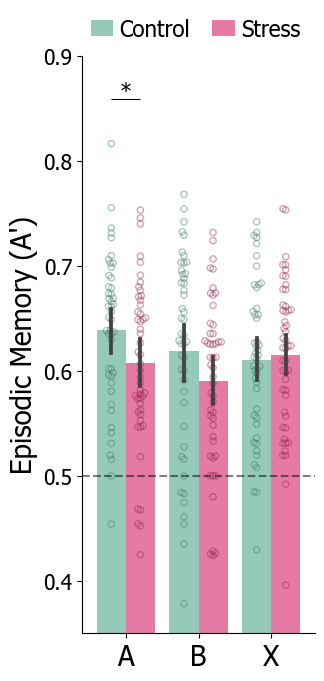

In [4]:
np.random.seed(0)
stat_type = "Aprime"
groups = ["Control", "Stress"]
abx = ["A", "B", "X"]

stats_df = {'subID': [], 'group': [], 'ABX': [], 'stat': []}

for group, use_subIDs in zip(["Control", "Stress"], [ctrl_subIDs, stress_subIDs]):
    for conds in [["A"], ["B"], ["X"]]:
        stats = behav_stats(use_subIDs, stat_type = stat_type, conds = conds)

        stats_df['subID'] += use_subIDs
        stats_df['group'] += [group]*len(use_subIDs)
        stats_df['ABX'] += conds*len(use_subIDs)
        stats_df['stat'] += stats
        
        # compute whether episodic memory from this group and cond is above chance (0.5)
        CI, pval = simple_bootstrap(np.array(stats), iterations=99999, CI_percentile=95, null=0.5, onetail_hyp='any')
        pval = 2*pval
        print(f"{conds[0]} {group}: 95% CI {[np.round(i, 5) for i in CI]}, p={np.round(pval, 5)}")

stats_df = pd.DataFrame(stats_df)

fig, ax = plt.subplots(1, 1, figsize=(3, 7.5))
sns.barplot(ax=ax, data=stats_df, x='ABX', hue = 'group', y='stat', palette=group_colors, saturation=1)
sns.swarmplot(ax=ax, data=stats_df, x='ABX', hue='group', y='stat', dodge=True, alpha=0, s=2, legend=False)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
sns.despine()
    
for groupi in range(len(groups)):
    for abxi in range(len(abx)):
        i = abxi*len(groups) + groupi
        x_data, y_data = ax.collections[i].get_offsets().T
    
        ax.scatter(x_data, y_data, color="None", s=20, alpha=0.4, edgecolor=dark_group_colors[groupi], linewidth=1)
        
        
# between group comparisons
np.random.seed(0)
print()
barxs = np.array([line.get_data()[0][0] for line in ax.get_lines()]).reshape(len(groups), len(abx)).T
scatterys = [np.max(stats_df[stats_df["ABX"] == s]["stat"]) for s in abx]
yshift = np.diff(ax.get_ylim())*0.05

for cond, condi in zip(abx, np.arange(len(abx))):
    ctrl_vals = np.array(stats_df.loc[(stats_df["group"] == "Control") & (stats_df["ABX"] == cond)]["stat"])
    stress_vals = np.array(stats_df.loc[(stats_df["group"] == "Stress") & (stats_df["ABX"] == cond)]["stat"])

    CI, pval = simple_bootstrap_2group(stress_vals, ctrl_vals, iterations=99999, CI_percentile=95, null=0, onetail_hyp='any')
    rbc = mannwhitneyu_effsize(stress_vals, ctrl_vals, alternative='two-sided')
    pval = 2*pval
    
    # add stars and bars
    stars = pval2star(pval)
    linex = barxs[condi]
    stary = scatterys[condi] + yshift
    if stars!='':
        ax.text(x=np.mean(linex), y=stary, s=stars, ha='center', fontsize=16)
        ax.hlines(xmin=linex[0], xmax=linex[1], y=stary, color='k', linewidth=0.8)
    
    print(f'{cond} Stress v Control: 95% CI {[np.round(i, 5) for i in CI]}, p = {np.round(pval, 5)}, rbc = {np.round(rbc, 5)}')
    

# within group comparisons - stats only (don't plot)
np.random.seed(0)
print()
for group in groups:
    for comparison in [["A", "X"], ["B", "X"]]:
        grp_df = stats_df.loc[(stats_df["group"] == group)]
        c1_vals = np.array(grp_df[grp_df["ABX"] == comparison[0]]["stat"])
        c2_vals = np.array(grp_df[grp_df["ABX"] == comparison[1]]["stat"])
        
        CI, pval = simple_bootstrap(c1_vals - c2_vals, iterations=99999, CI_percentile=95, null=0, onetail_hyp='any')
        rbc = wilcoxon_effsize(c1_vals-c2_vals, alternative='two-sided')
        pval = pval*2
        
        print(f'{comparison[0]} vs {comparison[1]} {group}: 95% CI {[np.round(i, 5) for i in CI]}, p={np.round(pval, 5)}, r={np.round(rbc, 5)}')
        
    
    
# LME predicting A' based on group and condition
anova_lme, effsize_lme = r_lme(stats_df, formula="stat ~ group * ABX", random_formula="~ 1 | subID", effsize=True)
print()
print(anova_lme)
print(effsize_lme[["partial.etasq", "statistic"]])

ax.hlines(0.5, -0.6, 2.6, color='k', linestyle='dashed', alpha=0.5)

ax.set_xlim([-0.6, 2.6])
ax.set_ylim([0.35, 0.9])
ax.set_ylabel("Episodic Memory (A')", fontsize=20)
ax.set_xlabel("")
ax.set_yticks(np.arange(0.4, 0.91, 0.1));
ax.set_xticklabels(abx, fontsize=20)

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(-0.05, 1.1), frameon=False, ncol=len(groups), handlelength=1, handletextpad=0.3, columnspacing=1, fontsize=16)
plt.plot();


In [5]:
# Save Aprime, HR, and FA for each subject and condition for further analysis
allcond_df = None
for stat_type in ['Aprime', 'HR', 'FA']:
    for cond in ['A', 'B', 'X']:
        stats_df = {'subID': [], f'{stat_type}_{cond}': []}
        stats = behav_stats(subIDs, stat_type = stat_type, conds = [cond])

        stats_df['subID'] = subIDs
        stats_df[f'{stat_type}_{cond}'] = stats
        stats_df = pd.DataFrame(stats_df)
        
        if allcond_df is None:
            allcond_df = stats_df
        else:
            allcond_df = pd.merge(allcond_df, stats_df, on='subID', how='left')
    
allcond_df.to_csv(behavrecog_savepath(), index=False)


### Cortisol Effects

In [6]:
recog_df = pd.read_csv("./midpoints/behavior/behav_recog.csv")[["subID", "Aprime_A"]]
cort_df = pd.read_csv("./midpoints/summary/Day1_cortisol_react.csv")[["subID", "group", "cort_react"]]
merge_df = pd.merge(recog_df, cort_df, on="subID", how="left")

r_lme(merge_df.dropna(), formula="Aprime_A ~ cort_react * group", random_formula="~ 1 | subID")

,numDF,denDF,F-value,p-value
(Intercept),1,77.0,5400.294589,0.000000
cort_react,1,77.0,1.090192,0.299696
group,1,77.0,2.854062,0.095189
cort_react:group,1,77.0,0.367649,0.546072


## 2. Statistical learning / pair familiarity (Supplemental Figure S5)

In [7]:
def behavfamil_stats(subIDs):
    '''
    Args:
        subIDs (list(int)): list of subject IDs to use
    '''
    
    famil = pd.read_csv('./data/behavior/familiarityData.csv', sep='\t')[["subID", "group", "acc"]]

    familacc = famil.groupby(by=["subID", "group"]).mean().reset_index()
    familacc = familacc.rename(columns = {"acc": "familacc"})
    familacc["group"] = familacc["group"].apply(lambda x: "Control" if x == 0 else "Stress")
        
    return familacc

Control: 0.045121951219512235, [0.43391360412637003, 0.544487427466151], 0.3594835948359484
Stress: 0.19797979797979798, [0.47306740878169456, 0.6128664192949911], 0.11442114421144212
Control vs Stress: 0.12418584455058612, [-0.03585994552559912, 0.14361389623547677], 0.23700237002370023


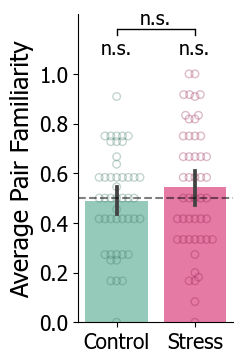

In [8]:
# Visualize subject-level statistical learning behavior
np.random.seed(0)

famildf = behavfamil_stats(subIDs)
groups = ["Control", "Stress"]

fig, ax = plt.subplots(1, 1, figsize=(2,4))
sns.barplot(ax=ax, data=famildf, x="group", y="familacc", palette=[ctrl_color, stress_color], order=["Control", "Stress"], saturation=1)
sns.swarmplot(ax=ax, data=famildf, 
              x="group", 
              hue="group", 
              y="familacc",
              legend=False,
              order=groups, hue_order=groups, 
              palette = ["darkgray", "darkgray"], 
              s=4,
              alpha=0)

for groupi in range(len(groups)):
    x_data, y_data = ax.collections[groupi].get_offsets().T
    ax.scatter(x_data, y_data, color="None", s=30, alpha=0.3, edgecolor=[dark_ctrl_color, dark_stress_color][groupi], linewidth=1)


#######################################################
# Compute statistics and add stars and bars to figure
#######################################################

ctrl_famil = np.array(famildf[famildf["group"] == "Control"]["familacc"])
stress_famil = np.array(famildf[famildf["group"] == "Stress"]["familacc"])

ctrl_CI, ctrl_p = simple_bootstrap(ctrl_famil, null=0.5, iterations=99999)
ctrl_rbc = wilcoxon_effsize(ctrl_famil-0.5, alternative="above")
ctrl_star = pval2star(ctrl_p)
ctrl_star = "n.s." if ctrl_star == '' else ctrl_star
print(f"Control: {ctrl_rbc}, {ctrl_CI}, {ctrl_p}")

stress_CI, stress_p = simple_bootstrap(stress_famil, null=0.5, iterations=99999)
stress_rbc = wilcoxon_effsize(stress_famil-0.5, alternative="above")
stress_star = pval2star(stress_p)
stress_star = "n.s." if stress_star == '' else stress_star
print(f"Stress: {stress_rbc}, {stress_CI}, {stress_p}")

CI, p = simple_bootstrap_2group(stress_famil, ctrl_famil, iterations=99999)
rbc = mannwhitneyu_effsize(stress_famil, ctrl_famil)
comp_star = pval2star(p)
comp_star = "n.s." if comp_star == '' else comp_star
print(f"Control vs Stress: {rbc}, {CI}, {p*2}")

barxs = [line.get_data()[0][0] for line in ax.get_lines()]
bary = 1
shifty = 0.06
textshift = 0.02


ax.text(s=ctrl_star, x=barxs[0], y=bary+shifty+textshift, ha="center", fontsize=14)
ax.text(s=stress_star, x=barxs[1], y=bary+shifty+textshift, ha="center", fontsize=14)
ax.text(s=comp_star, x=np.mean(barxs), y=bary+shifty*3+textshift, ha="center", fontsize=14)
ax.hlines(y=bary+shifty*3, xmin=barxs[0], xmax=barxs[1], color='k', linewidth=1)
ax.vlines(x=barxs[0], ymin=bary+shifty*2.6, ymax=bary+shifty*3, color='k', linewidth=1, capstyle="projecting")
ax.vlines(x=barxs[1], ymin=bary+shifty*2.6, ymax=bary+shifty*3, color='k', linewidth=1, capstyle="projecting")

ax.set_ylim([0, bary+shifty*4])
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.axhline(0.5, color='k', linestyle='dashed', alpha=0.5)
ax.set_xlabel("")
ax.set_ylabel("Average Pair Familiarity")
sns.despine()

plt.plot();


In [9]:
# Save subject-level familiarity data for future analysis
famildf.to_csv(behavfamil_savepath(), index=False)


### Cortisol Effects

In [10]:
famil_df = pd.read_csv("./midpoints/behavior/behav_famil.csv")[["subID", "familacc"]]
cort_df = pd.read_csv("./midpoints/summary/Day1_cortisol_react.csv")[["subID", "group", "cort_react"]]
merge_df = pd.merge(famil_df, cort_df, on="subID", how="left")

r_lme(merge_df.dropna(), formula=f"familacc ~ cort_react * group", random_formula="~ 1 | subID")

,numDF,denDF,F-value,p-value
(Intercept),1,77.0,440.431343,0.000000
cort_react,1,77.0,1.319001,0.254327
group,1,77.0,0.284440,0.595342
cort_react:group,1,77.0,0.074478,0.785655
